# Exploratory Data Analysis
## Credit Card Transaction Fraud Dataset

This notebook provides an initial exploratory analysis of the credit card transaction dataset using pandas. The goal is to understand the dataset structure, identify data quality issues, examine class imbalance, and highlight features that may be useful for later PySpark-based analysis and fraud modeling.

In [1]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np

## Accessing, Loading, and Previewing our Data

In [2]:
repo_root = Path.cwd().parent
data_file = repo_root / "data" / "raw" / "credit_card_transactions.csv"

print(data_file)
print(data_file.exists())

df = pd.read_csv(data_file)
df.head()

/home/jovyan/work/data/raw/credit_card_transactions.csv
True


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


## Dataset Overview

We begin by reviewing the size and structure of the dataset. This helps establish the scale of the problem, identify column types, and determine which variables may need conversion or transformation before deeper analysis.

In [3]:
print(f'Rows: {df.shape[0]}\nColumns: {df.shape[1]}\n')
df.info()

Rows: 1296675
Columns: 24

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  floa

## Datetime Conversion

The `trans_date_trans_time` column is initially loaded as a string (`object`). Converting it to a datetime format allows us to derive time-based features such as hour, day, month, and weekday, which may be useful for identifying fraud patterns over time.

In [4]:
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"],
    format="%Y-%m-%d %H:%M:%S"
)

df["trans_date_trans_time"].dtype

dtype('<M8[ns]')

### Derived Time Features

After converting the transaction timestamp, we create several derived columns to support temporal analysis:

- `hour` to examine time-of-day behavior
- `day` to inspect day-of-month patterns
- `month` to identify seasonality
- `weekday` to compare behavior across the week

In [5]:
df["hour"] = df["trans_date_trans_time"].dt.hour
df["day"] = df["trans_date_trans_time"].dt.day
df["month"] = df["trans_date_trans_time"].dt.month
df["weekday"] = df["trans_date_trans_time"].dt.day_name()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 28 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Unnamed: 0             1296675 non-null  int64         
 1   trans_date_trans_time  1296675 non-null  datetime64[ns]
 2   cc_num                 1296675 non-null  int64         
 3   merchant               1296675 non-null  object        
 4   category               1296675 non-null  object        
 5   amt                    1296675 non-null  float64       
 6   first                  1296675 non-null  object        
 7   last                   1296675 non-null  object        
 8   gender                 1296675 non-null  object        
 9   street                 1296675 non-null  object        
 10  city                   1296675 non-null  object        
 11  state                  1296675 non-null  object        
 12  zip                    12966

### Missing Values

The dataset appears to have minimal missing data. The only missing values are in `merch_zipcode`. Because merchant latitude and longitude are already available, this field may not be necessary for initial analysis and can likely be excluded without major information loss.

In [6]:
df.isnull().sum().sort_values(ascending=False)

merch_zipcode            195973
Unnamed: 0                    0
trans_date_trans_time         0
month                         0
day                           0
hour                          0
is_fraud                      0
merch_long                    0
merch_lat                     0
unix_time                     0
trans_num                     0
dob                           0
job                           0
city_pop                      0
long                          0
lat                           0
zip                           0
state                         0
city                          0
street                        0
gender                        0
last                          0
first                         0
amt                           0
category                      0
merchant                      0
cc_num                        0
weekday                       0
dtype: int64

#### Checking Duplicated Data

In [7]:
df.duplicated().sum()

np.int64(0)

<p>There is no duplicated data in this dataset for us to account for.</p>

## Fraud Ground Truth

The `is_fraud` column provides the target variable for this dataset. Because fraudulent transactions are typically rare in real-world payment data, we expect this dataset to be strongly imbalanced. Understanding that imbalance early is important because it affects both analysis and later modeling choices.

### Class Imbalance

We calculate the proportion of fraudulent and non-fraudulent transactions to understand how sparse the fraud class is. This imbalance is expected, but it also means that summary statistics and visualizations should be interpreted carefully.

In [8]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

## Vizualizations

## Distribution Review

To make the histogram view more informative, we create a visualization-specific dataframe (`df_hist`) that excludes identifiers, timestamps, and other fields that are not meaningful for raw distribution plots.

In [9]:
df_hist = df.copy()

drop_cols = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "amt",
    "zip",
    "merch_zipcode",
    "cc_num",
    "city_pop",
    "trans_num",
    "unix_time",
    "first",
    "last"
]

df_hist = df_hist.drop(columns=[col for col in drop_cols if col in df_hist.columns])

df_hist = df_hist.select_dtypes(include=["number"])

The remaining variables provide a more interpretable view of the dataset's numerical structure. At this stage, the goal is not to draw final conclusions, but to identify unusual distributions, skew, clustering, and candidate variables for deeper analysis.

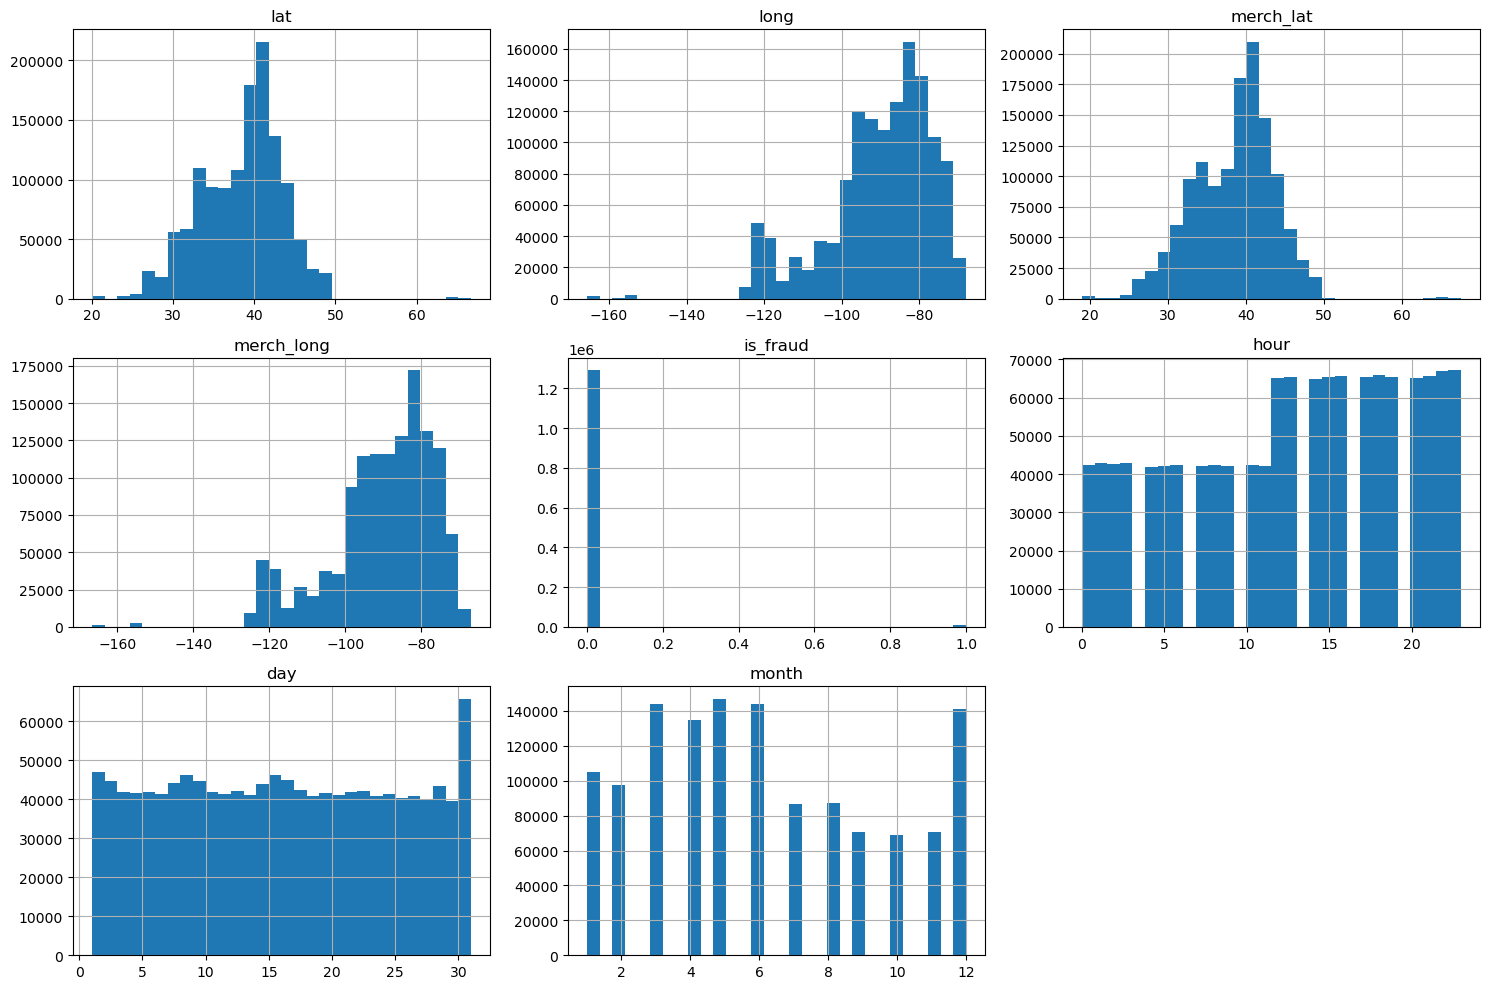

In [10]:
df_hist.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

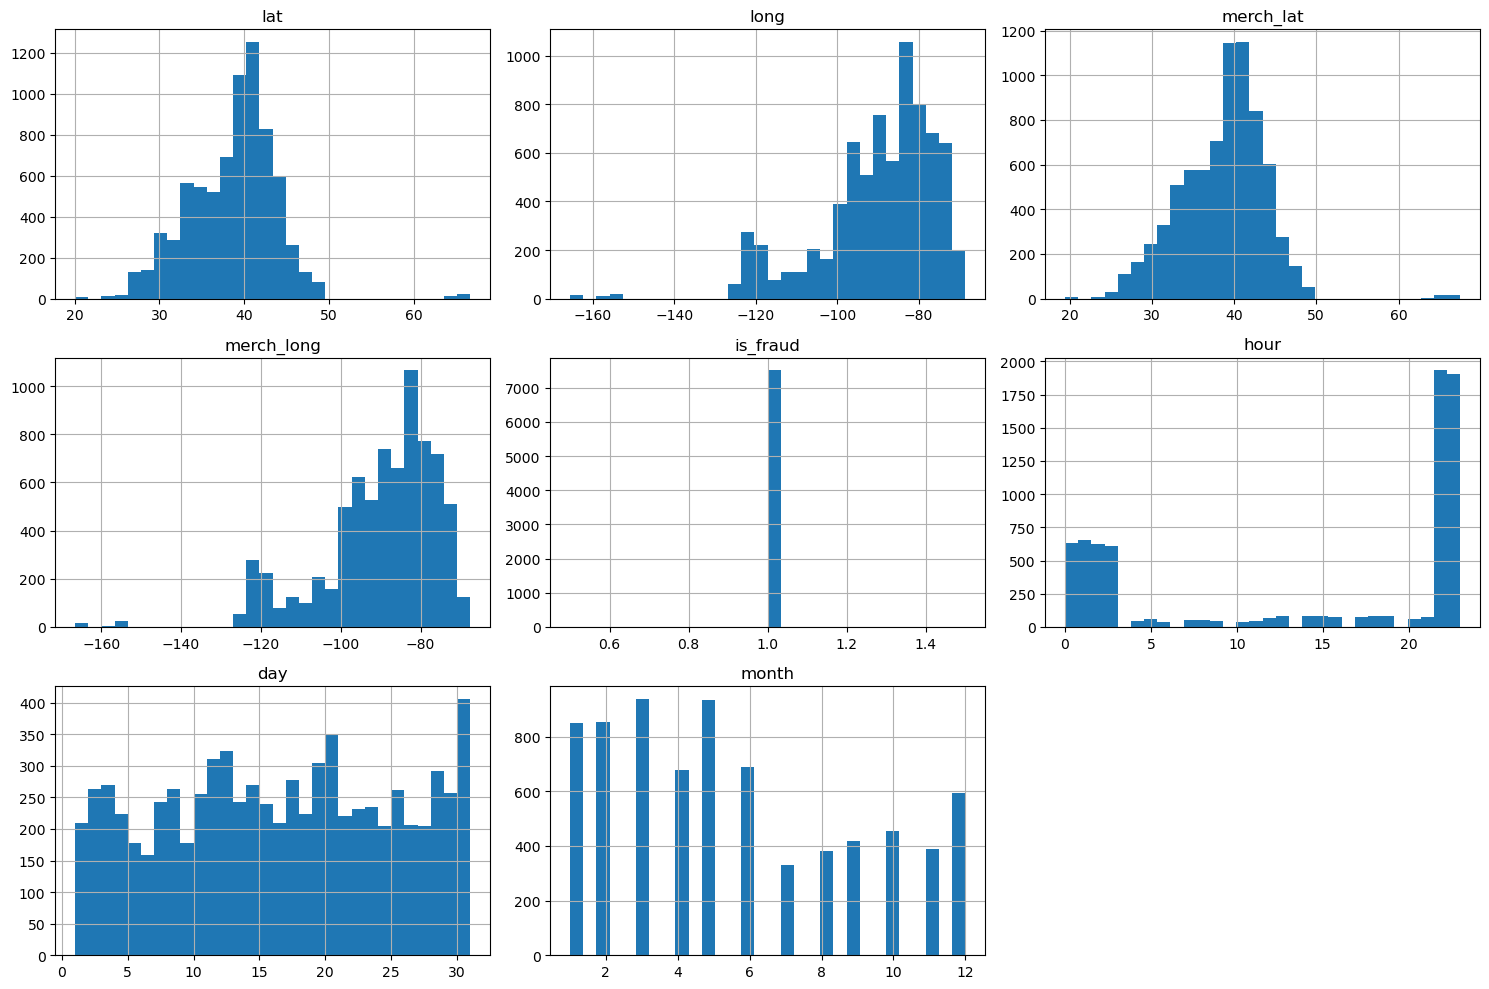

In [19]:
df_fraud_hist = df_hist.copy()

df_fraud_hist = df_hist[df_hist["is_fraud"] == 1]
df_fraud_hist.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

## Initial Observations

Several early patterns appear in the distributions:

### Time-Based Patterns
Transaction activity varies by month, day, and hour. Some months and days appear more active than others, and transaction volume increases later in the day.

### Class-Specific Differences
Fraudulent transactions appear to differ from non-fraudulent transactions in both amount and geographic distribution.

### Implications for Later Analysis
These early findings suggest that transaction amount, time-based features, and spatial features may all be useful candidates for deeper fraud analysis.

## Transaction Amount Comparison

Transaction amount is one of the most intuitive variables to inspect. Because legitimate transactions include a much wider range of values than fraudulent transactions, we compare the two classes separately to avoid having the fraud distribution visually compressed by the larger non-fraud range.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Non-fraud
axes[0].hist(df[df["is_fraud"] == 0]["amt"], bins=500)
axes[0].set_xlim(0, 2000)
axes[0].set_title("Non-Fraud (0–2000 Range)")
axes[0].set_ylabel("Count of Transactions")
axes[0].set_xlabel("Amount")

# Fraud
axes[1].hist(df[df["is_fraud"] == 1]["amt"], bins=50)
axes[1].set_title("Fraud Transactions")
axes[1].set_ylabel("Count of Transactions")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()

The amount distributions suggest that fraud is concentrated in lower-value transactions, while legitimate transactions include a broader range and much larger outliers. This difference may make transaction amount a useful predictive feature.

## Geographic Fraud Density

Customer location data allows us to inspect whether fraudulent transactions cluster geographically. At this stage, the goal is exploratory: to see whether fraud appears randomly distributed or concentrated in certain areas.

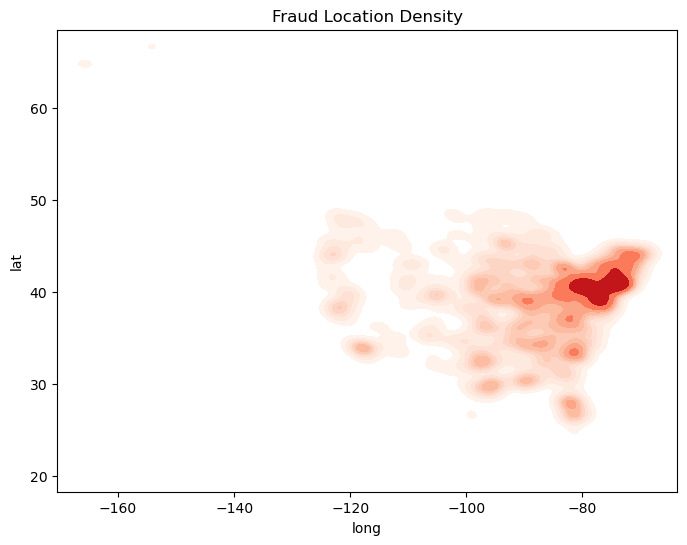

In [13]:
fraud_df = df[df["is_fraud"] == 1]

plt.figure(figsize=(8,6))

sns.kdeplot(
    x=fraud_df["long"],
    y=fraud_df["lat"],
    fill=True,
    cmap="Reds",
    bw_adjust=0.5
)

plt.title("Fraud Location Density")
plt.show()

The fraud density plot suggests that fraudulent transactions may not be uniformly distributed across geography. This supports later exploration of location-based features such as merchant distance, customer-to-merchant displacement, and regional patterns.

## Correlation Review

To identify potentially useful numerical relationships, we examine the correlation matrix for numeric features only. Because this dataset includes both identifiers and engineered values, correlation is used here as a directional exploratory tool rather than a final feature-selection method.

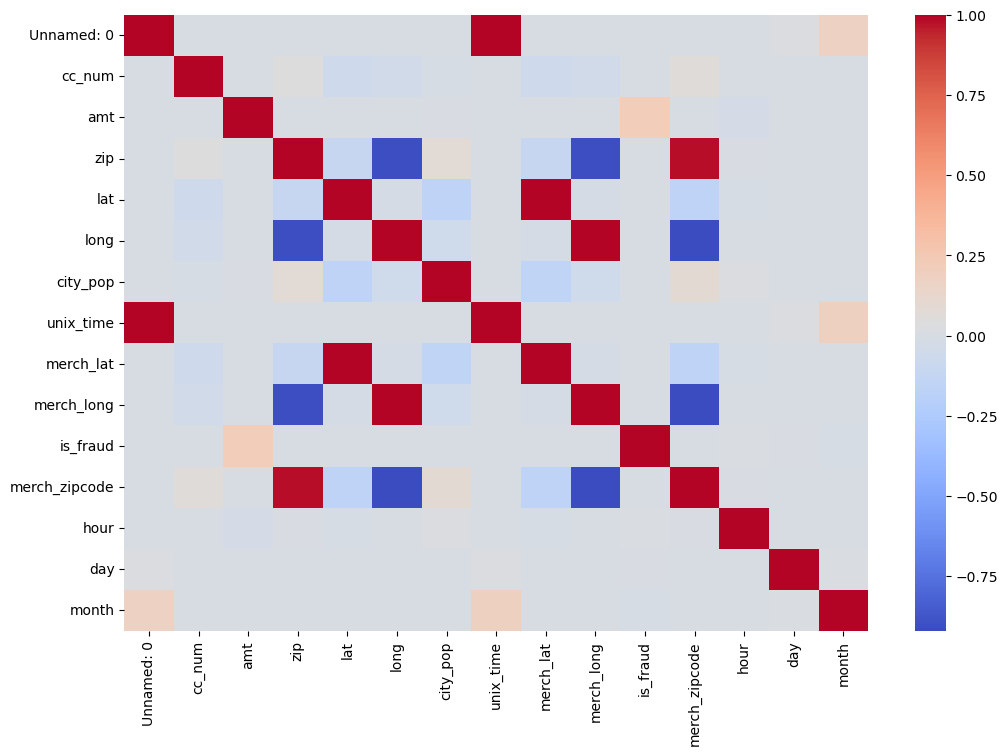

In [14]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.show()

The correlation matrix helps highlight which numerical variables may have stronger linear relationships with one another and with the fraud label. However, correlation alone should not be treated as proof of predictive usefulness, especially in an imbalanced fraud dataset.

## EDA Takeaways

This exploratory analysis identified several important characteristics of the dataset:

- Fraud is highly imbalanced relative to non-fraud transactions
- Transaction timestamps provide useful derived temporal features
- Transaction amounts are strongly skewed and differ by class
- The dataset contains minimal missing data
- Geographic patterns may be useful for further fraud analysis

These findings provide a foundation for the next stage of the project, where larger-scale transformations and aggregations can be implemented in PySpark.